# Анализ представленных данных (EDA)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Считывание данных

In [ ]:
df = pd.read_excel("raw_data.xlsx")

print(f'Размерность датасета: {df.shape}')
df.head()

Размерность датасета: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


Сразу удалим лишнюю столбец индексов - Unnamed: 0

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 213 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    IC50, mM                  1001 non-null   float64
 1    CC50, mM                  1001 non-null   float64
 2    SI                        1001 non-null   float64
 3    MaxAbsEStateIndex         1001 non-null   float64
 4    MaxEStateIndex            1001 non-null   float64
 5    MinAbsEStateIndex         1001 non-null   float64
 6    MinEStateIndex            1001 non-null   float64
 7    qed                       1001 non-null   float64
 8    SPS                       1001 non-null   float64
 9    MolWt                     1001 non-null   float64
 10   HeavyAtomMolWt            1001 non-null   float64
 11   ExactMolWt                1001 non-null   float64
 12   NumValenceElectrons       1001 non-null   int64  
 13   NumRadicalElectrons       1001 non-null   int6

In [ ]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,348.262234,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,126.946370,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,409.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


## Исследование и первичная предобработка данных

### Проверим пропуски, дубли и распределение признаков

Исследуем датасет на наличие пропусков в признаках

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

,0
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MWLOW,3
BCUT2D_CHGHI,3
BCUT2D_CHGLO,3
BCUT2D_LOGPHI,3
BCUT2D_LOGPLOW,3


Найдено незначительное кол-во пропусков - в 12 признаках по 3 пропуска в каждом, заполним их медианным значением.

In [ ]:
df = df.fillna(df.median())
df.isnull().sum().sum()


np.int64(0)

Проверим наличие дубликатов и удалим их

In [ ]:
df.duplicated().sum()

np.int64(32)

In [ ]:
df = df.drop_duplicates()
df

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,414.542,...,0,0,0,0,0,0,0,0,0,0
997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,485.621,...,0,0,0,0,0,0,0,0,0,0
998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,545.742,...,1,0,0,0,0,0,0,0,0,0
999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,522.635,...,0,0,0,0,0,0,0,0,0,0


После замены пропусков на медиану и удаления дубликатов имеем 213 признаков и 969 записей

### Анализ распределений целевых признаков и выбросов

Построим гистограмму с ядерной оценки плотности (KDE) для распределения и корорбку с усами для выбросов.

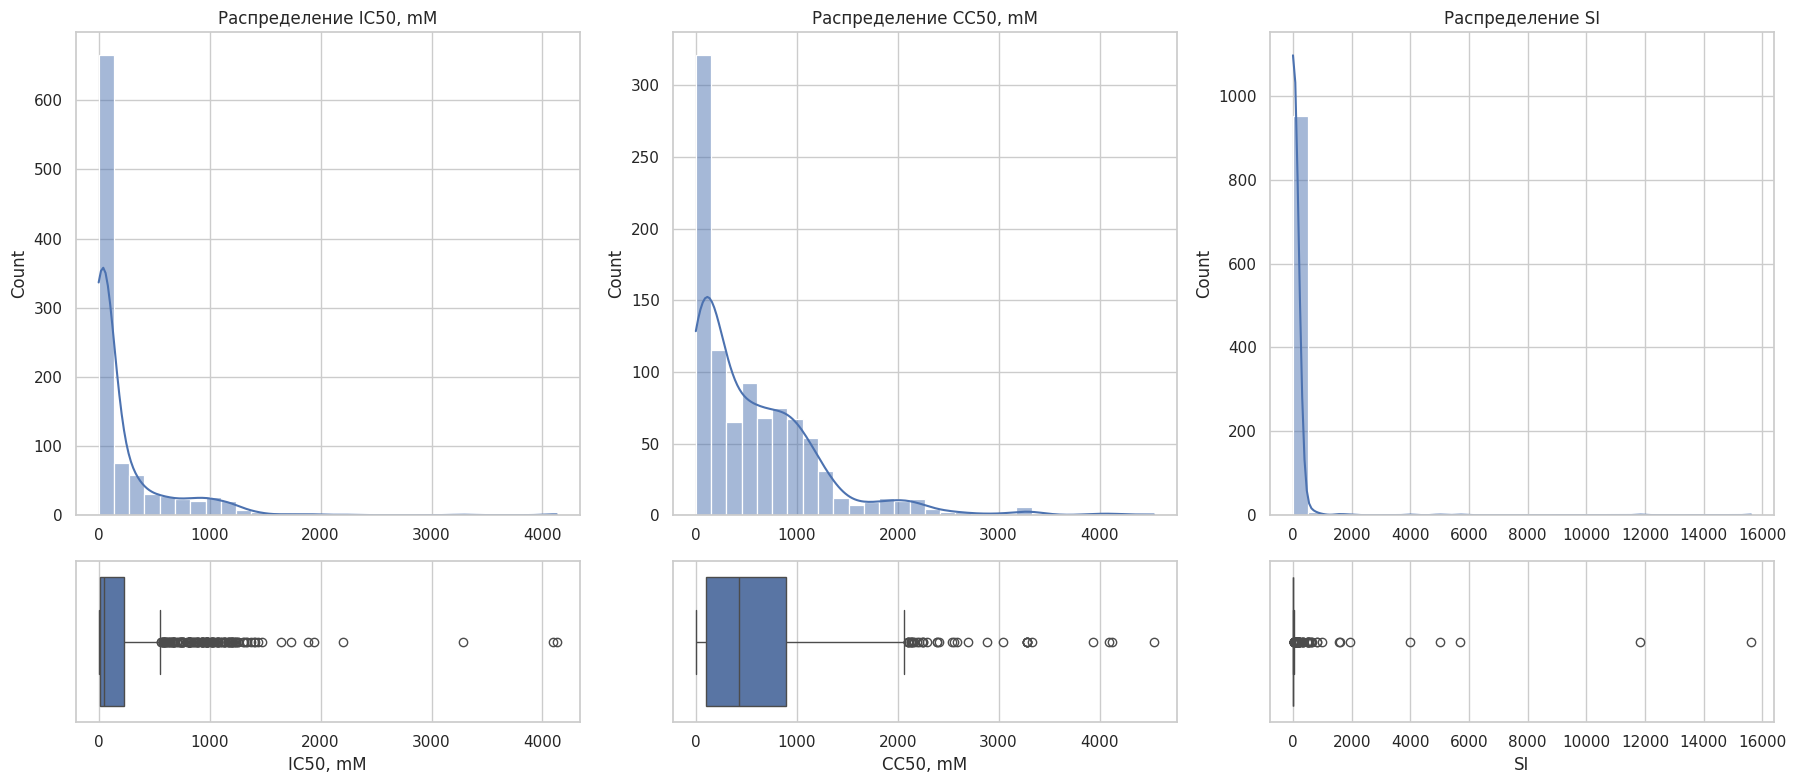

In [ ]:
sns.set(style="whitegrid")

targets = ['IC50, mM', 'CC50, mM', 'SI']

fig, axes = plt.subplots( 2, 3, figsize=(18, 8),
    gridspec_kw={'height_ratios': [3, 1]}
)

for i, col in enumerate(targets):
    ax1 = axes[0, i]
    ax2 = axes[1, i]

    # Гистограмма + KDE
    sns.histplot(df[col], kde=True, bins=30, ax=ax1)
    ax1.set_title(f'Распределение {col}')
    ax1.set_xlabel('')

    # Коробка с усами
    sns.boxplot(x=df[col], ax=ax2)
    ax2.set_xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in targets:
    stat, p = stats.shapiro(df[col].sample(min(500, len(df))))
    print(col, p)

IC50, mM 3.819942865450551e-33
CC50, mM 4.0061853212854157e-25
SI 5.582963819523222e-44


Значения p-value для всех трех целевых переменных близки к 0 (далеко ниже 0.05). Это означает, что распределение каждой из этих переменых статистически значимо отличается от нормального.

В дальнейшем нужно будет предварительно логарифмировать эти переменные, чтобы приблизить их распределение к нормальному.

In [ ]:
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    mask = (
        (df[col] >= Q1 - 1.5 * IQR) &
        (df[col] <= Q3 + 1.5 * IQR)
    )
    outliers_pct = (1 - mask.mean()) * 100

    print(f"{col}: {outliers_pct:.2f}% выбросов")
    return outliers_pct

print("Доля выбросов:")
for col in targets:
    count_outliers(df, col)

Доля выбросов:
IC50, mM: 14.24% выбросов
CC50, mM: 3.61% выбросов
SI: 12.38% выбросов


Доля выбросов представлена выше, однако удалять их не будем так как c большей вероятностью это негативно повлияет на обучение моделей, так как:

 - По определению SI = CC50/IC50. IC50 - это ингибирующая концентрация, СC50 - это цитотоксическая концентрация, на основе которых вычислен индекс селективности SI. Экстремальные значения SI означают либо высокоэффективные (низкий IC50), либо нетоксичные (высокий CC50) соединения.

 - Потеря примерно 15% данных при 1000 соединений снижает статистическую мощность и обобщающую способность модели, а также может исключить лучших кандидатов в лекарства.

 - Удаление искажает распределение - мы искусственно сузим диапазон IC50/CC50, что приведет к смещенным метрикам.

 - Дополнительно алгоритмы, которые будут использоованы в дальнейшем — случайный лес, градиентный бустинг и другие хорошо работают с выбросами.



### Корреляционный анализ

Рассмотрим матрицу корреляций всех признаков

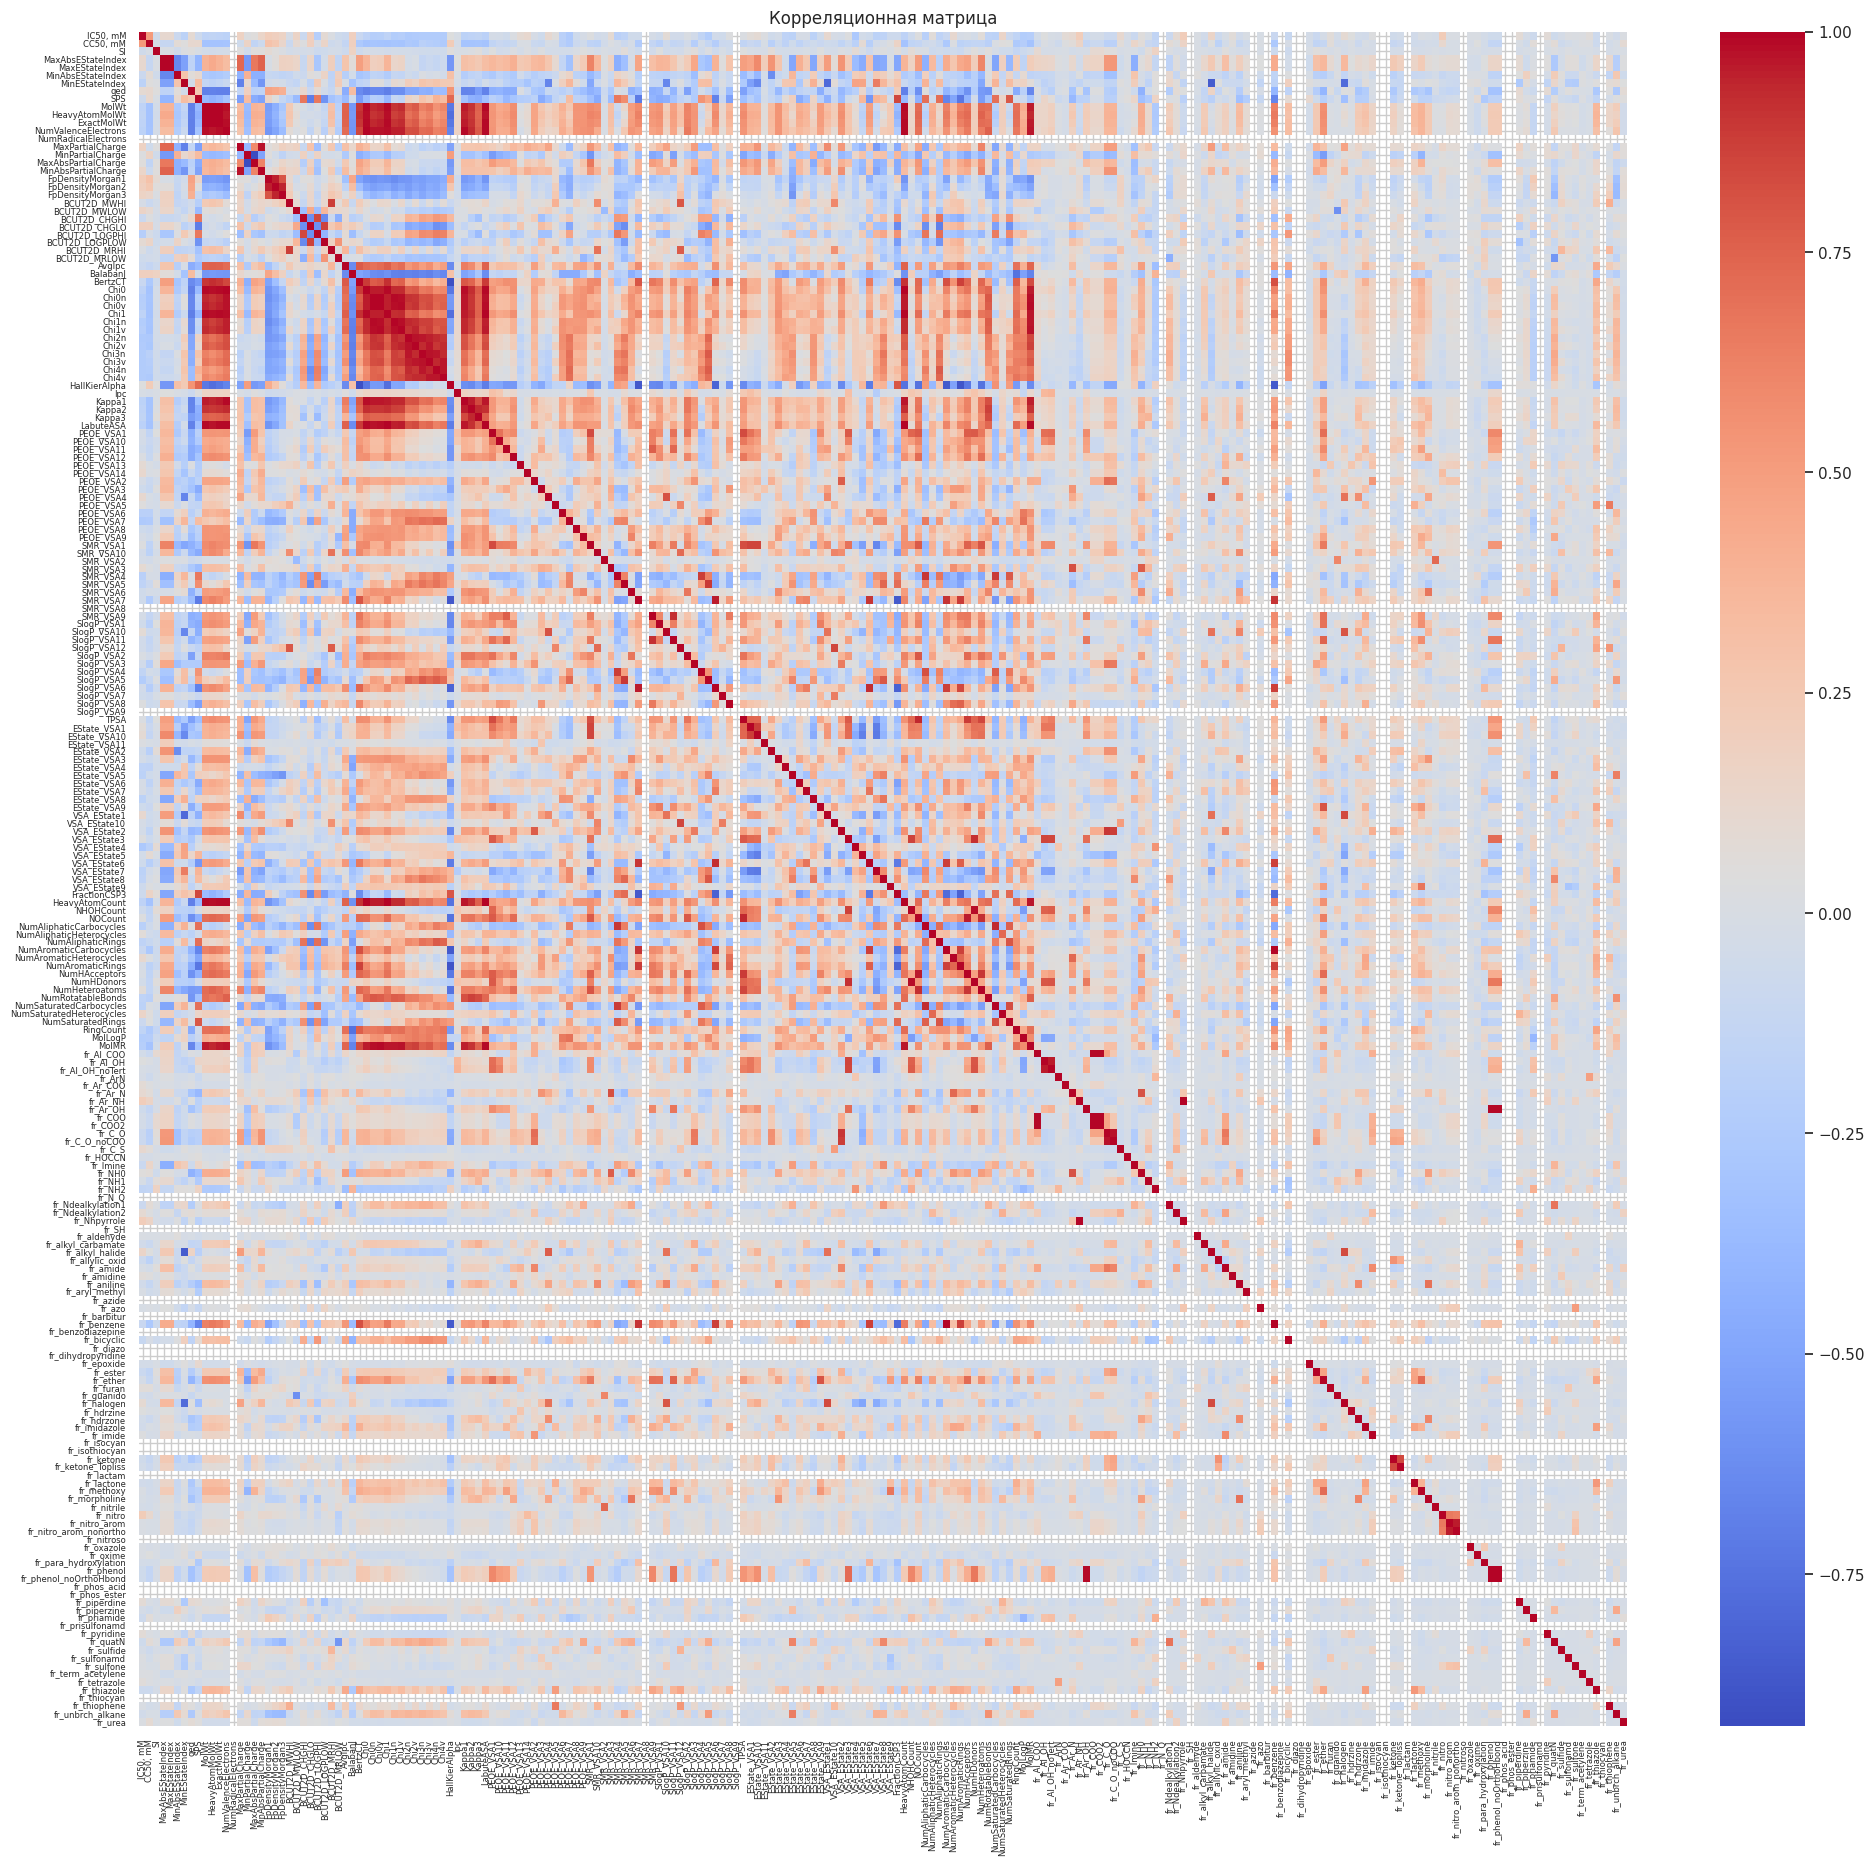

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(24, 22))
sns.heatmap(corr, annot=False, cmap='coolwarm', xticklabels=True, yticklabels=True)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.title('Корреляционная матрица')
plt.show()


Из диаграммы выше можно сделать общий вывод о том, что большая часть признаков, которая коррелирует между собой расположена в второй четверти графика. Преимкщественно это положительная корреляция, но также наблюдается и отрицательная.

Рассмотрим корреляцию подмножества наиболее значимых признаков.

Изучив опредления признаков в датасете, стоит проанализировать ряд признаков представленных ниже.


Функциональные фрагменты:
- fr_amide - амидная группа - ключевой элемент для связывания с ферментами и GPCR.
- fr_Ar_N - атом азота в ароматическом кольце, который часто участвует в π-стэкинг и водородных связях.

Физико-химические свойства:
- MolWt - молекулярный вес.
- MolLogP - липофильность - влияет на проникновение через мембраны и связывание с гидрофобными карманами белка.
- TPSA - топологическая площадь полярной поверхности.
- qed (Quantitative Estimate of Drug-likeness) - количественная оценка "лекарственноподобности", коррелирует с безопасностью.

Топологические и электронные свойства:
- NumHDonors/NumHAcceptors - Доноры/акцепторы водородных связей, количество и расположение которых влияет на связывание.
- NumRotatableBonds - вращаемые связи, демонстрируют гибкость молекулы, из-за большого кол-ва связей теряется специфичность.
- NumAromaticRings - ароматические кольца, π-стэкинг с ароматическими аминокислотами.

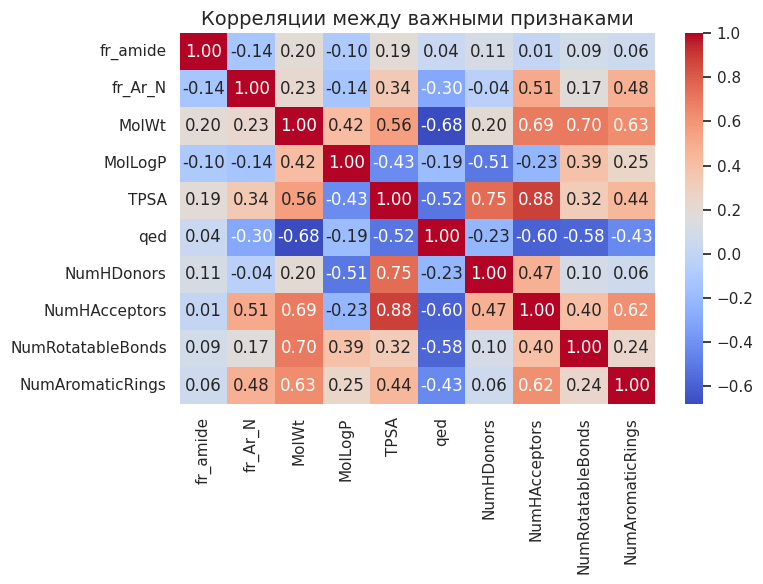

In [ ]:
top10_features = ['fr_amide','fr_Ar_N','MolWt','MolLogP','TPSA',
                  'qed','NumHDonors','NumHAcceptors',
                  'NumRotatableBonds','NumAromaticRings']
corr_subset = corr[top10_features].loc[top10_features]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции между важными признаками', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df[top10_features].describe().T

,count,mean,std,min,25%,50%,75%,max
fr_amide,969.0,0.347781,0.708419,0.000000,0.000000,0.000000,0.000000,4.000000
fr_Ar_N,969.0,0.599587,1.273798,0.000000,0.000000,0.000000,1.000000,12.000000
MolWt,969.0,351.486139,127.388186,110.156000,266.252000,318.373000,413.670000,904.777000
MolLogP,969.0,3.452764,2.157542,-5.750700,2.449200,3.432800,4.537720,12.822200
TPSA,969.0,62.081950,45.980973,0.000000,29.460000,49.770000,83.760000,407.500000
qed,969.0,0.577633,0.213316,0.059567,0.442842,0.634372,0.742483,0.947265
NumHDonors,969.0,1.179567,1.604087,0.000000,0.000000,1.000000,2.000000,15.000000
NumHAcceptors,969.0,4.411765,3.220657,0.000000,2.000000,4.000000,5.000000,25.000000
NumRotatableBonds,969.0,3.867905,3.296174,0.000000,2.000000,3.000000,5.000000,28.000000
NumAromaticRings,969.0,1.497420,1.399618,0.000000,0.000000,1.000000,2.000000,7.000000


По результатам анализа корреляционной матрицы можно выявить несколько важных закономерностей:
- Наиболее сильная положительная корреляция наблюдается между TPSA и NumHAcceptors (0.88), а также между MolWt и NumRotatableBonds (0.70). Это объяснется тем, что увеличение молекулярной массы закономерно ведет к росту числа акцепторов водородных связей и повышению гибкости молекулы.
- qed имеет умеренную отрицательную связь с MolWt (-0.68) и NumHAcceptors (-0.60). Это означает, что крупные молекулы с большим количеством акцепторов считаются менее лекарственноподобными.
- Наличие ароматических атомов азота (fr_Ar_N) умеренно коррелирует с NumAromaticRings (0.48) и NumHAcceptors (0.51), указывая на то, что ароматические атомы вносят вклад в общее число акцепторов.
- Стоит также обратить внимание на то, что слабая связь qed с fr_amide (0.04) и MolLogP (-0.19) говорит о том, что наличие амидной группы и липофильность в отдельности не определяют лекарственноподобность молекулы.
- NumHDonors практически не коррелирует с NumAromaticRings (0.06) и слабо с fr_Ar_N (-0.04), что свидетельствует о том, что доноры водородных связей в основном сосредоточены в алифатических фрагментах.

Дополнительно рассмотрим распределение этих признаков:

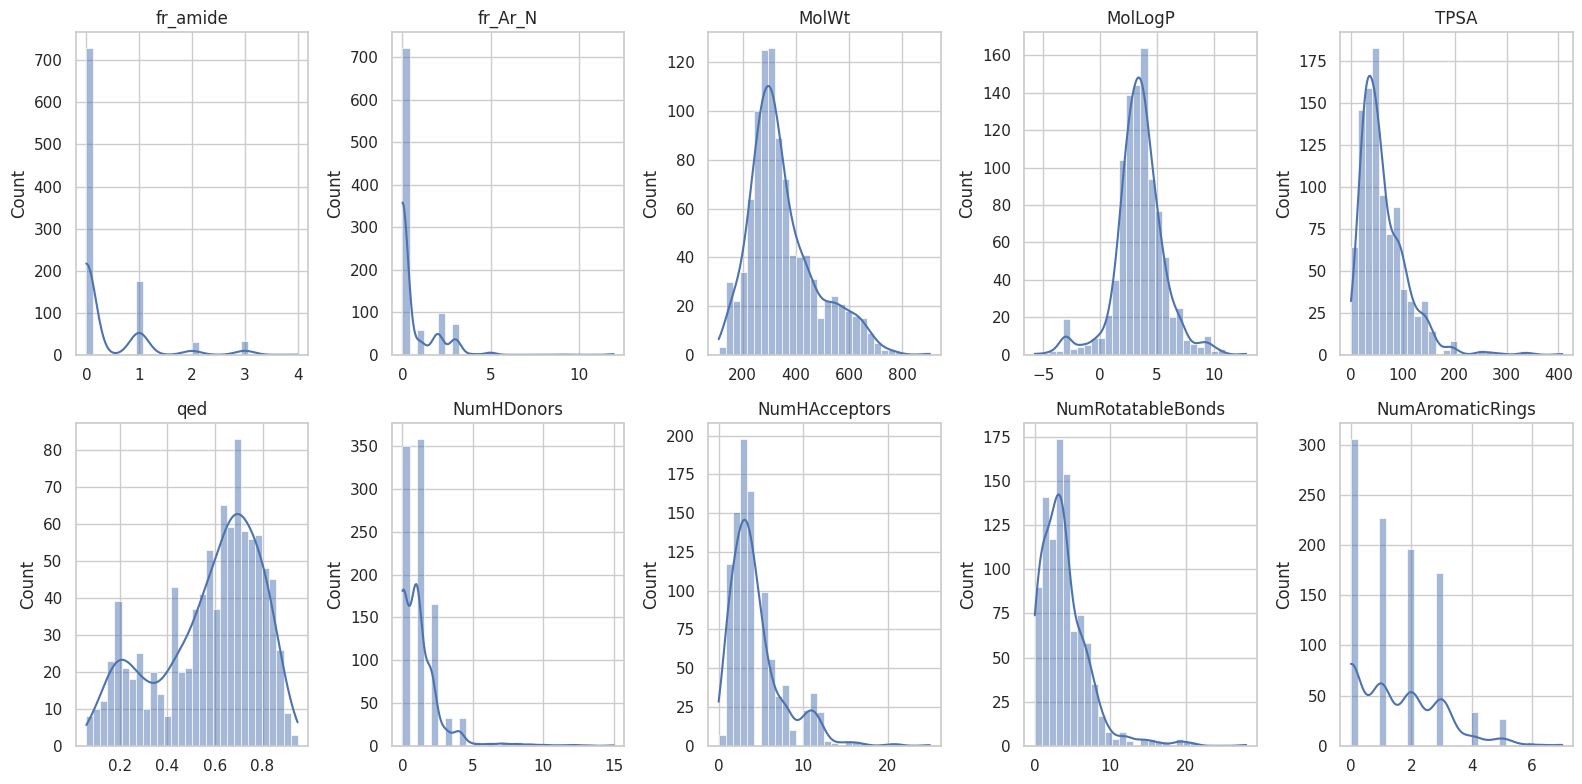

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top10_features):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')

for j in range(len(top10_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Из графиков распределения выше можно сделать вывод о том, что признаки обладают различным спектром распределений и что важно разными масштабами. Это означает что в дальнейшем нужно будет масштабировать признаки перед использованием моделей.

In [ ]:
df.to_csv("/data/clean_data.csv", index=False)

**Общий вывод:**

В ходе первичной предобработки данных было выявлено, что датасет содержит незначительное количество пропусков, которые были заполнены медианными значениями. Дубли удалены. Таким образом, итоговый датасет для дальнейшего использования для моделей включает 969 записей и 213 признаков.

Анализ распределений целевых переменных - IC50, CC50 и индекса селективности SI — показал, что все они статистически значимо отличаются от нормального распределения. Это обосновывает необходимость их логарифмического преобразования перед построением моделей.

Доля выбросов в целевых признаках варьируется, однако было принято решение не удалять их, поскольку большие значения SI соответствуют потенциально наиболее важным соединениям. Кроме того, удаление выбросов привело бы к потере статистической мощности и искажению распределений, тогда как используемые в дальнейшем алгоритмы устойчивы к выбросам.

Корреляционный анализ позволил выявить ожидаемые взаимосвязи между признаками. Наиболее сильная положительная корреляция наблюдается между топологической площадью полярной поверхности и числом акцепторов водородных связей, а также между молекулярной массой и числом вращаемых связей. Показатель лекарственноподобности QED отрицательно коррелирует с молекулярной массой и числом акцепторов, что подтверждает, что крупные молекулы с большим количеством акцепторов считаются менее лекарственноподобными.

Также установлено, что признаки имеют различные масштабы и типы распределений, что требует их масштабирования перед использованием в моделях машинного обучения.

